In [34]:
from tools import get_metadata, get_volume, plot_pod_energy, plot_pod_modes, import_as_xarray
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

In [35]:
ds = import_as_xarray(get_metadata('golf_slice_c1.h5', 'c1'))

In [49]:
sliced_ds = ds.isel(x=0)  # Example: take the first vertical slice

# Extract the velocity field (assuming 'u' is the variable of interest)
Ut = sliced_ds.u.values

In [37]:
# Data shape: (600, 6, 26) -> (t, z, y)
nt, nz, ny = Ut.shape
n_spatial_points = nz * ny

# 1. Reshape for Snapshot POD: (Spatial Points, Snapshots)
# We transpose to get (z*y, t)
X = Ut.transpose(1, 2, 0).reshape(n_spatial_points, nt)

# 2. Subtract the Time-Mean (Fluctuations)
mean_flow = np.mean(X, axis=1, keepdims=True)
X_prime = X - mean_flow

# 3. Snapshot POD Correlation Matrix (nt x nt)
# Since nt (600) is larger than n_spatial (156), 
# computing X_prime.T @ X_prime is efficient.
C = np.dot(X_prime.T, X_prime) / nt

# 4. Solve Eigenvalue Problem
eigvals, eigvecs = linalg.eigh(C)

# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# 5. Calculate Spatial Modes
# phi = X' * eigvecs. Shape: (156, 600)
modes = np.dot(X_prime, eigvecs)
# Normalize modes so their spatial norm is 1
modes = modes / np.linalg.norm(modes, axis=0)

Snapshot Matrix X ready. Shape: (156, 600)
Performing SVD...


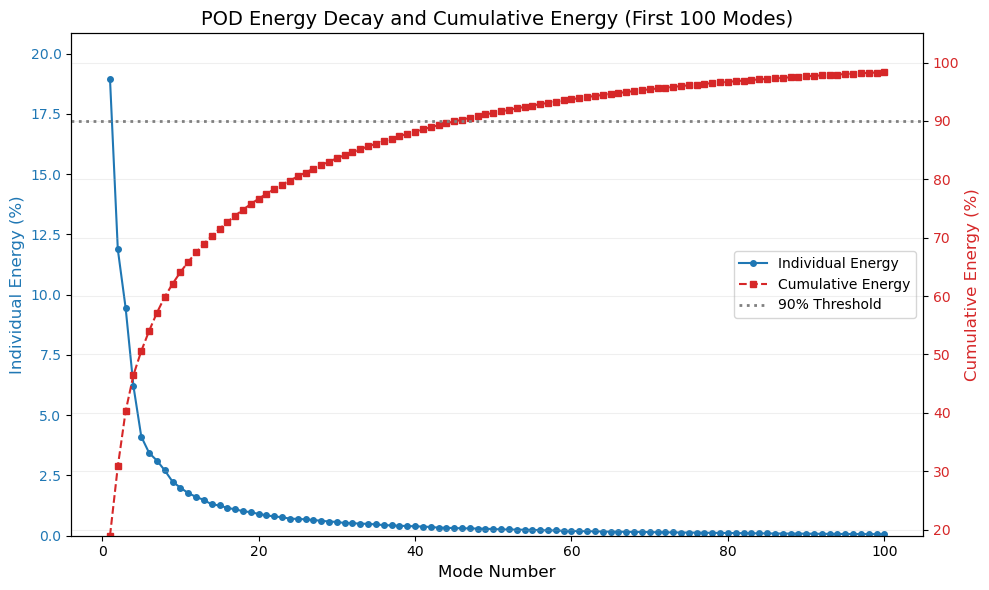

----------------------------------------
Number of modes to reach 90% energy: 46
Energy in the first 20 modes: 76.66%
----------------------------------------


In [38]:
# --- 4. SNAPSHOT MATRIX CONSTRUCTION ---
# X_prime is already in the correct shape (SpatialPoints, Time) = (156, 600)
Xp = X_prime
print(f"Snapshot Matrix X ready. Shape: {Xp.shape}")

# --- 5. ECONOMY SVD (POD Calculation) ---
print("Performing SVD...")
U_modes, Sigma, Vt = np.linalg.svd(Xp, full_matrices=False)

# --- 6. ENERGY CALCULATION ---
energy = Sigma**2
total_energy = np.sum(energy)
relative_energy = (energy / total_energy) * 100
cumulative_energy = np.cumsum(relative_energy)

plot_pod_energy(relative_energy, cumulative_energy)

# 90% Milestone Print
n_90 = np.argmax(cumulative_energy >= 90) + 1
print("-" * 40)
print(f"Number of modes to reach 90% energy: {n_90}")
print(f"Energy in the first 20 modes: {cumulative_energy[19]:.2f}%")
print("-" * 40)

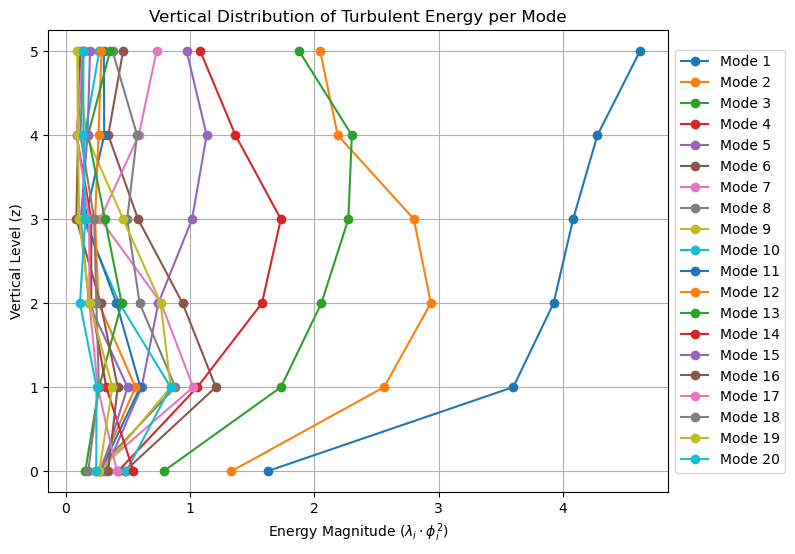

In [39]:
# Prepare a matrix to store energy per height for the top modes
n_top_modes = 20
energy_z_profile = np.zeros((nz, n_top_modes))

for i in range(n_top_modes):
    # Reshape the 1D mode back to (z, y)
    phi_i = modes[:, i].reshape(nz, ny)
    
    # Calculate energy at each height z by summing across y
    # This gives us the "weight" of mode i at each height
    energy_z = np.sum(phi_i**2, axis=1) 
    
    # Weight by the eigenvalue (actual energy magnitude)
    energy_z_profile[:, i] = energy_z * eigvals[i]

# --- VISUALIZATION ---
plt.figure(figsize=(8, 6))
z_coords = np.arange(nz) # Or sliced_ds.z.values

for i in range(n_top_modes):
    plt.plot(energy_z_profile[:, i], z_coords, '-o', label=f'Mode {i+1}')

plt.title("Vertical Distribution of Turbulent Energy per Mode")
plt.xlabel(r"Energy Magnitude ($\lambda_i \cdot \phi_i^2$)")
plt.ylabel("Vertical Level (z)")
# move legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.show()

In [44]:
# --- 7. PS-ROM RECONSTRUCTION (using n modes) ---
def create_rom(U_modes, Sigma, Vt, n_modes, prime = False):
    # Reconstruct fluctuations: (SpatialPoints x n_modes) @ (n_modes x Time)
    X_rom_prime = U_modes[:, :n_modes] @ (np.diag(Sigma[:n_modes]) @ Vt[:n_modes, :])

    # Reshape back to 4D: (SpatialPoints, Time) -> (Time, Z, Y)
    u_rom_prime = X_rom_prime.T.reshape(nt, nz, ny)  # Assuming original spatial shape was (nz, ny)

    if prime:
        return u_rom_prime
    # Reshape mean back to spatial dimensions and add it
    mean_flow_reshaped = mean_flow.reshape(nz, ny)

    u_rom = u_rom_prime + mean_flow_reshaped

    return u_rom

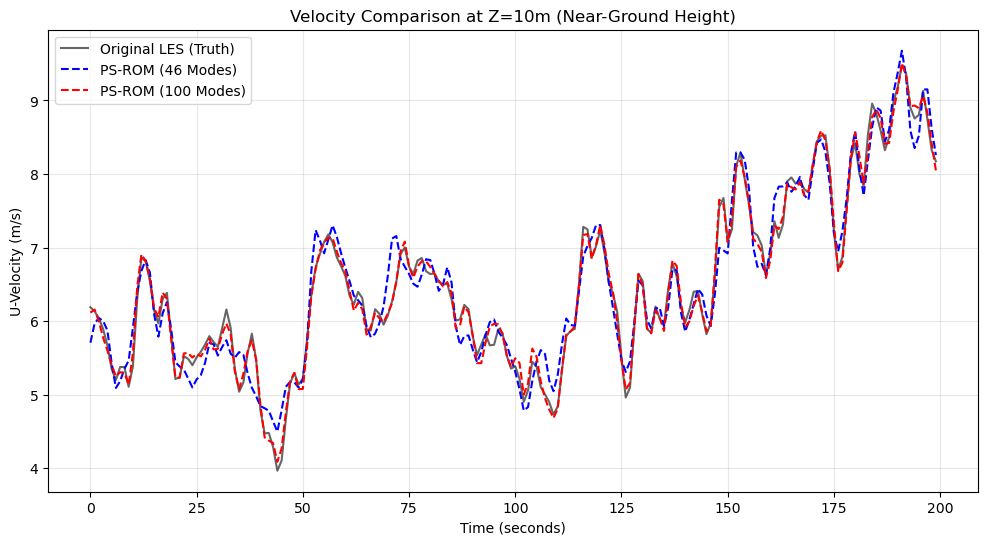

In [43]:
# --- 8. COMPARISON PLOT (Time Series) ---
# Choose a probe point: near-ground-height (index 1), Center of field
z_idx, y_idx = 1, nz//2

end_t = 200

plt.figure(figsize=(12, 6))

# Plot Original LES (The "Truth")
plt.plot(Ut[:end_t, z_idx, y_idx], 
         label='Original LES (Truth)', color='black', alpha=0.6)

# Plot PS-ROM Reconstruction
n_modes = 46 # 90% energy threshold
u_rom = create_rom(U_modes, Sigma, Vt, n_modes)
plt.plot(u_rom[:end_t, z_idx, y_idx], 
         label=f'PS-ROM ({n_modes} Modes)', color='blue', linestyle='--')

n_modes = 100
u_rom = create_rom(U_modes, Sigma, Vt, n_modes)
plt.plot(u_rom[:end_t, z_idx, y_idx], 
         label=f'PS-ROM ({n_modes} Modes)', color='red', linestyle='--')

plt.title(f"Velocity Comparison at Z={z_idx*10}m (Near-Ground Height)")
plt.xlabel("Time (seconds)")
plt.ylabel("U-Velocity (m/s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

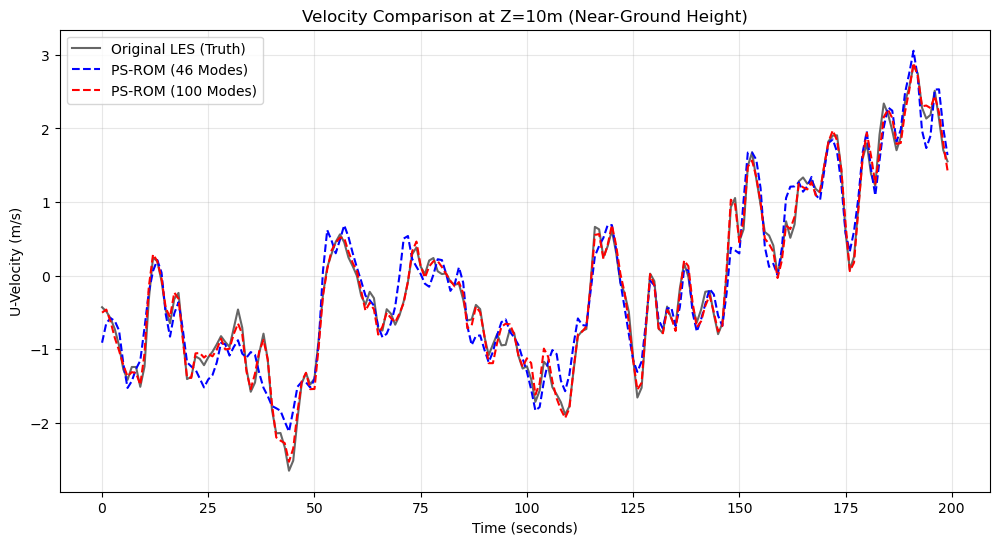

In [46]:
# --- 8. COMPARISON PLOT (Time Series) ---
# Choose a probe point: near-ground-height (index 1), Center of field
z_idx, y_idx = 1, nz//2

end_t = 200

plt.figure(figsize=(12, 6))

# Plot Original LES (The "Truth")
plt.plot(X_prime.T.reshape(nt, nz, ny)[:end_t, z_idx, y_idx], 
         label='Original LES (Truth)', color='black', alpha=0.6)

# Plot PS-ROM Reconstruction
n_modes = 46 # 90% energy threshold
u_rom = create_rom(U_modes, Sigma, Vt, n_modes, prime=True)
plt.plot(u_rom[:end_t, z_idx, y_idx], 
         label=f'PS-ROM ({n_modes} Modes)', color='blue', linestyle='--')

n_modes = 100
u_rom = create_rom(U_modes, Sigma, Vt, n_modes, prime=True)
plt.plot(u_rom[:end_t, z_idx, y_idx], 
         label=f'PS-ROM ({n_modes} Modes)', color='red', linestyle='--')

plt.title(f"Velocity Comparison at Z={z_idx*10}m (Near-Ground Height)")
plt.xlabel("Time (seconds)")
plt.ylabel("U-Velocity (m/s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

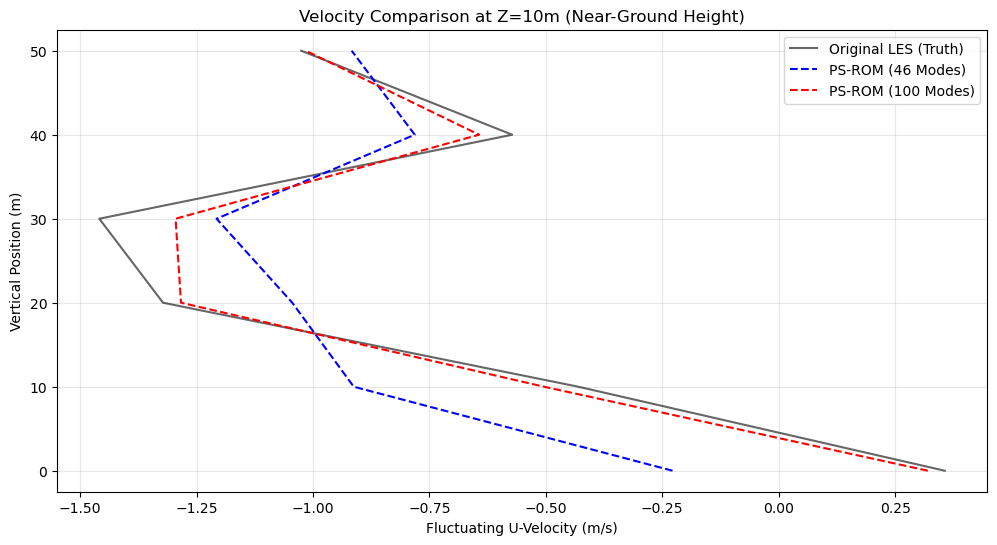

In [48]:
# --- 8. COMPARISON PLOT (Time Series) ---
# Choose a probe point: near-ground-height (index 1), Center of field
t_idx, y_idx = 0, nz//2

z = np.arange(nz) * 10  # Assuming 10m vertical spacing

plt.figure(figsize=(12, 6))

# Plot Original LES (The "Truth")
plt.plot(X_prime.T.reshape(nt, nz, ny)[t_idx, :, y_idx], z,
         label='Original LES (Truth)', color='black', alpha=0.6)

# Plot PS-ROM Reconstruction
n_modes = 46 # 90% energy threshold
u_rom = create_rom(U_modes, Sigma, Vt, n_modes, prime=True)
plt.plot(u_rom[t_idx, :, y_idx], z,
         label=f'PS-ROM ({n_modes} Modes)', color='blue', linestyle='--')

n_modes = 100
u_rom = create_rom(U_modes, Sigma, Vt, n_modes, prime=True)
plt.plot(u_rom[t_idx, :, y_idx], z,
         label=f'PS-ROM ({n_modes} Modes)', color='red', linestyle='--')

plt.title(f"Velocity Comparison at Z={z_idx*10}m (Near-Ground Height)")
plt.xlabel("Fluctuating U-Velocity (m/s)")
plt.ylabel("Vertical Position (m)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()